In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd().parent

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "fetal" / "oxford_female"

print("="*60)
print("Oxford FEMaLe Dataset Exploration")
print("="*60)

print("Dataset Path :", DATASET_PATH)
print("Exists :", DATASET_PATH.exists())

Oxford FEMaLe Dataset Exploration
Dataset Path : c:\Users\Asus\OneDrive\Desktop\fetal_assesment_project\data\raw\fetal\oxford_female
Exists : True


In [2]:
all_files = sorted(DATASET_PATH.glob("*.mat"))

print(f"Total MAT files : {len(all_files)}")

for file in all_files:
    print(file.name)

Total MAT files : 32
154100_bp.mat
154100_signal.mat
450569_bp.mat
450569_signal.mat
450663_bp.mat
450663_signal.mat
451043_bp.mat
451043_signal.mat
451049_bp.mat
451049_signal.mat
451280_bp.mat
451280_signal.mat
451377_bp.mat
451377_signal.mat
451421_bp.mat
451421_signal.mat
451609_bp.mat
451609_signal.mat
451625_bp.mat
451625_signal.mat
451743_bp.mat
451743_signal.mat
451875_bp.mat
451875_signal.mat
451898_bp.mat
451898_signal.mat
451905_bp.mat
451905_signal.mat
451927_bp.mat
451927_signal.mat
451993_bp.mat
451993_signal.mat


In [3]:
signal_files = sorted(DATASET_PATH.glob("*signal*.mat"))
marker_files = sorted(DATASET_PATH.glob("*bp*.mat"))

print(f"Signal Files : {len(signal_files)}")
print(f"Marker Files : {len(marker_files)}")

# Inspect first signal file (if present) to report dtype, shape, and memory usage
if len(signal_files) > 0:
	sample_mat = loadmat(signal_files[0])
	vars_in_mat = [k for k in sample_mat.keys() if not k.startswith("__")]
	print("Sample file :", signal_files[0].name)
	print("Variables  :", vars_in_mat)
	# pick a likely signal variable
	sig_key = None
	for k in vars_in_mat:
		if "BCG" in k or "signal" in k.lower() or "preproc" in k.lower():
			sig_key = k
			break
	if sig_key is None and vars_in_mat:
		sig_key = vars_in_mat[0]
	data = sample_mat[sig_key]
	print("Signal Variable :", sig_key)
	print("Shape           :", getattr(data, "shape", "Unknown"))
	print("Dtype           :", getattr(data, "dtype", "Unknown"))
	print("Memory (bytes)  :", data.nbytes if hasattr(data, "nbytes") else "Unknown")
else:
	print("No signal files found.")

Signal Files : 16
Marker Files : 16
Sample file : 154100_signal.mat
Variables  : ['BCG_PREPROC_3AXIS']
Signal Variable : BCG_PREPROC_3AXIS
Shape           : (154099, 3)
Dtype           : float64
Memory (bytes)  : 3698376


In [4]:
# ============================================================
# Load Sample Recording
# ============================================================

sample_signal = signal_files[0]

mat = loadmat(sample_signal)

for key in mat:
    if not key.startswith("__"):
        print(mat[key][:5])
        break

sample_signal_data = mat["BCG_PREPROC_3AXIS"]

print(f"Shape : {sample_signal_data.shape}")
for key in mat:
    
    if not key.startswith("__"):
        
        print(key)

        print(type(mat[key]))

        print(np.shape(mat[key]))

        print("-"*40)


[[-11.1187119  -10.67746345 -16.52264813]
 [-11.11998505 -10.67669098 -16.52255514]
 [-11.1207468  -10.67973081 -16.52514079]
 [-11.12269945 -10.68231289 -16.52299145]
 [-11.12380452 -10.68345014 -16.52184704]]
Shape : (154099, 3)
BCG_PREPROC_3AXIS
<class 'numpy.ndarray'>
(154099, 3)
----------------------------------------


In [5]:
# ============================================================
# Signal Preview
# ============================================================

display(pd.DataFrame(
    sample_signal_data,
    columns=["X", "Y", "Z"]
).head())

,X,Y,Z
0,-11.118712,-10.677463,-16.522648
1,-11.119985,-10.676691,-16.522555
2,-11.120747,-10.679731,-16.525141
3,-11.122699,-10.682313,-16.522991
4,-11.123805,-10.683450,-16.521847


In [6]:
# ============================================================
# Inspect Push Button File
# ============================================================

# ensure bp_files is defined (uses marker_files defined earlier)
bp_files = marker_files
sample_bp = bp_files[0]

bp = loadmat(sample_bp)

print(bp.keys())

for key in bp:

    if "__" not in key:

        print("\n", key)
        print("Shape :", bp[key].shape)
        print(bp[key][:10])

dict_keys(['__header__', '__version__', '__globals__', 'BP_MOUV_FILES'])

 BP_MOUV_FILES
Shape : (154100, 1)
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [7]:
# ============================================================
# Recording Statistics
# ============================================================

summary = []

SAMPLING_RATE = 500  # Hz

for file in signal_files:

    mat = loadmat(file)

    current_signal = mat["BCG_PREPROC_3AXIS"]

    samples = current_signal.shape[0]

    duration_sec = samples / SAMPLING_RATE

    summary.append({
        "Recording": file.stem,
        "Samples": samples,
        "Duration (sec)": round(duration_sec, 2),
        "Duration (min)": round(duration_sec / 60, 2)
    })

recording_summary = pd.DataFrame(summary)

# Overall Statistics
recording_summary["Minimum Duration (sec)"] = recording_summary["Duration (sec)"].min()
recording_summary["Maximum Duration (sec)"] = recording_summary["Duration (sec)"].max()
recording_summary["Average Duration (sec)"] = round(
    recording_summary["Duration (sec)"].mean(), 2
)

display(recording_summary)

,Recording,Samples,Duration (sec),Duration (min),Minimum Duration (sec),Maximum Duration (sec),Average Duration (sec)
0,154100_signal,154099,308.20,5.14,308.2,903.99,865.76
1,450569_signal,450569,901.14,15.02,308.2,903.99,865.76
2,450663_signal,450663,901.33,15.02,308.2,903.99,865.76
3,451043_signal,451042,902.08,15.03,308.2,903.99,865.76
4,451049_signal,451049,902.10,15.03,308.2,903.99,865.76
5,451280_signal,451280,902.56,15.04,308.2,903.99,865.76
6,451377_signal,451377,902.75,15.05,308.2,903.99,865.76
7,451421_signal,451421,902.84,15.05,308.2,903.99,865.76
8,451609_signal,451609,903.22,15.05,308.2,903.99,865.76
9,451625_signal,451625,903.25,15.05,308.2,903.99,865.76


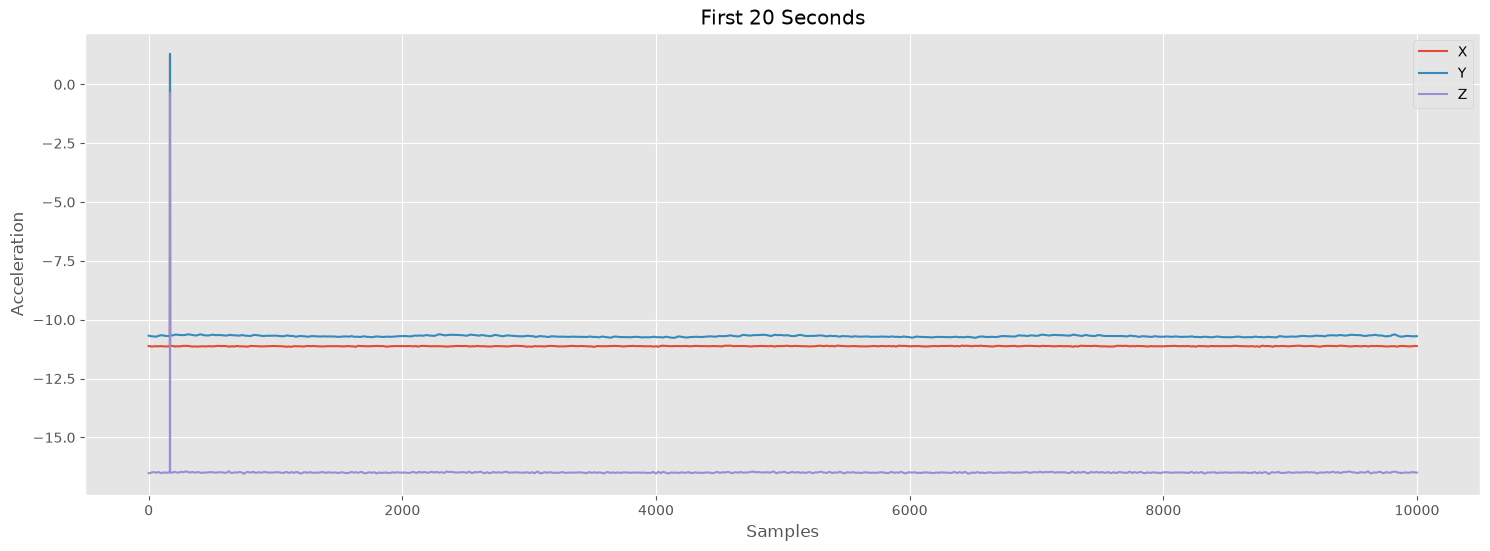

In [8]:
plt.figure(figsize=(18,6))

seconds = 20

samples = seconds * 500

plt.plot(sample_signal_data[:samples,0],label="X")
plt.plot(sample_signal_data[:samples,1],label="Y")
plt.plot(sample_signal_data[:samples,2],label="Z")

plt.legend()

plt.title("First 20 Seconds")

plt.xlabel("Samples")

plt.ylabel("Acceleration")

plt.show()

In [9]:
df = pd.DataFrame(sample_signal_data, columns=["X","Y","Z"])

display(df.describe())

,X,Y,Z
count,154099.000000,154099.000000,154099.000000
mean,-11.152139,-10.552867,-16.463740
std,0.070556,0.279692,0.088048
min,-13.953871,-18.127743,-20.861132
25%,-11.190806,-10.731181,-16.501466
50%,-11.142988,-10.650799,-16.482086
75%,-11.119112,-10.448784,-16.445383
max,1.266035,1.298529,-0.371447


In [10]:
stats = pd.DataFrame({

"Mean":df.mean(),

"Std":df.std(),

"Min":df.min(),

"Max":df.max(),

"RMS":np.sqrt((df**2).mean())

})

display(stats)

,Mean,Std,Min,Max,RMS
X,-11.152139,0.070556,-13.953871,1.266035,11.152362
Y,-10.552867,0.279692,-18.127743,1.298529,10.556573
Z,-16.463740,0.088048,-20.861132,-0.371447,16.463975


X Dominant Frequency : 0.00 Hz
X Dominant Magnitude : 2722.49
Y Dominant Frequency : 0.00 Hz
Y Dominant Magnitude : 23900.54
Z Dominant Frequency : 0.00 Hz
Z Dominant Magnitude : 4342.88


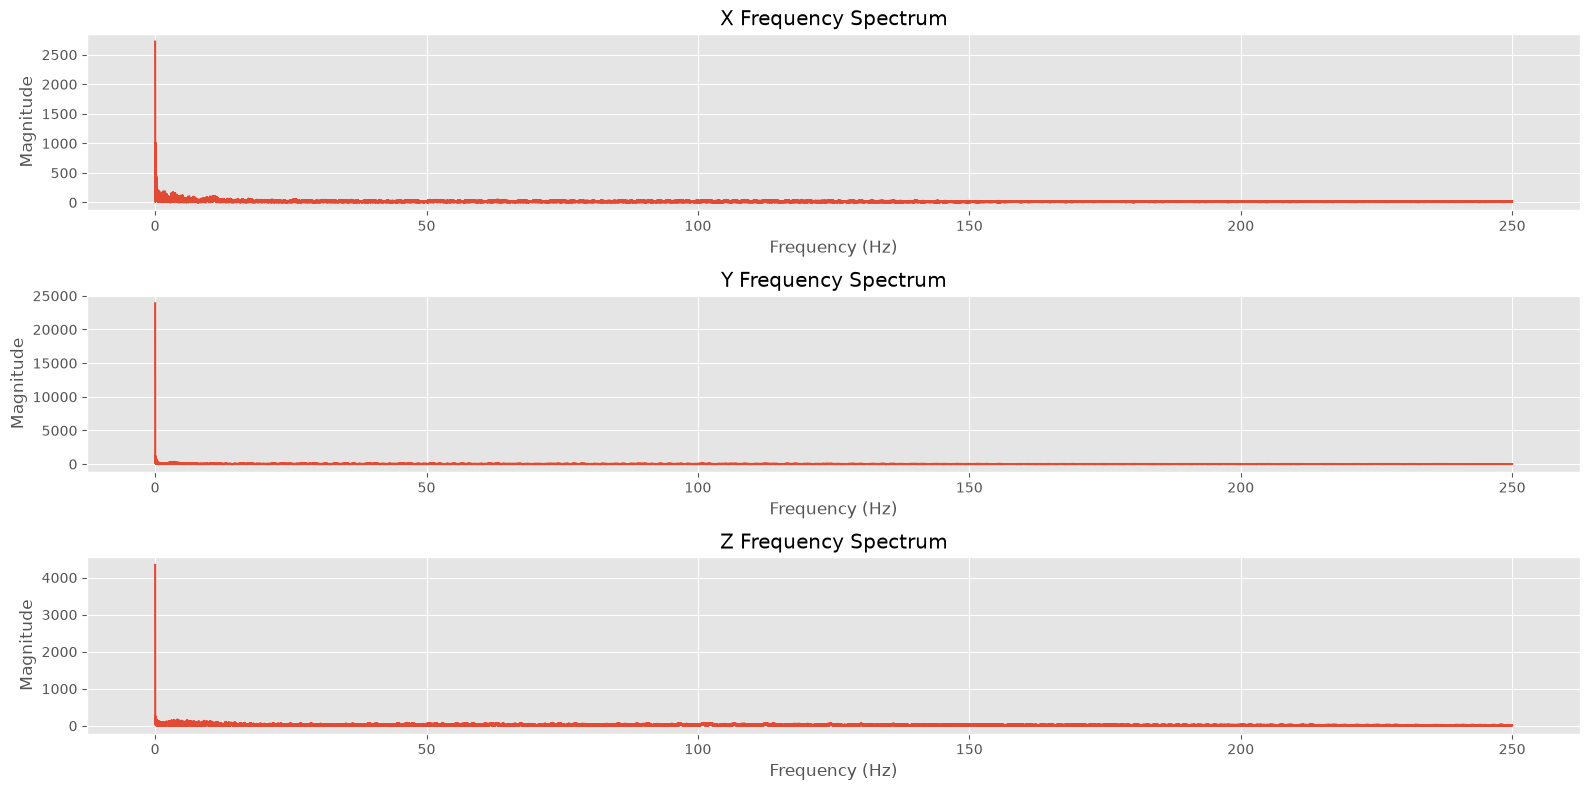

In [11]:
from scipy.fft import fft, fftfreq

fs = 500

axis_names = ["X", "Y", "Z"]

plt.figure(figsize=(16,8))

for i in range(3):

    signal = sample_signal_data[:, i]

    N = len(signal)

    yf = np.abs(fft(signal))

    xf = fftfreq(N, 1/fs)

    positive = xf > 0

    xf = xf[positive]
    yf = yf[positive]

    peak_idx = np.argmax(yf)
    peak_frequency = xf[np.argmax(yf)]
    peak_magnitude = yf[peak_idx]

    print(f"{axis_names[i]} Dominant Frequency : {peak_frequency:.2f} Hz")
    print(f"{axis_names[i]} Dominant Magnitude : {peak_magnitude:.2f}")

    plt.subplot(3,1,i+1)

    plt.plot(xf, yf)

    plt.title(f"{axis_names[i]} Frequency Spectrum")

    plt.xlabel("Frequency (Hz)")

    plt.ylabel("Magnitude")

plt.tight_layout()

plt.show()

In [12]:
# ============================================================
# Dataset Metadata Summary
# ============================================================

metadata = pd.DataFrame({

"Property":[
"Dataset",
"Subjects",
"Sensor",
"Axes",
"Sampling Rate",
"Recording Format",
"Label Type",
"Ground Truth"
],

"Value":[
"Oxford FEMaLe",
len(signal_files),
"ADXL355 Accelerometer",
"3-axis",
"500 Hz",
".mat",
"Maternal Push Button",
"Mother Perception"
]

})

display(metadata)

,Property,Value
0,Dataset,Oxford FEMaLe
1,Subjects,16
2,Sensor,ADXL355 Accelerometer
3,Axes,3-axis
4,Sampling Rate,500 Hz
5,Recording Format,.mat
6,Label Type,Maternal Push Button
7,Ground Truth,Mother Perception


In [13]:
# ============================================================
# Push Button Characterization
# ============================================================

bp = loadmat(bp_files[0])

for key in bp:

    if "__" not in key:

        data = bp[key]

        print("="*50)

        print("Variable :", key)

        print("Shape :", data.shape)

        print()

        print(data[:20])

Variable : BP_MOUV_FILES
Shape : (154100, 1)

[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [14]:
# ============================================================
# Push Button Dataset Summary (To Be Implemented)
# ============================================================

summary=[]

for file in bp_files:

    bp=loadmat(file)

    for key in bp:

        if "__" not in key:

            d=bp[key]

            summary.append({

                "Recording": file.stem,
                "Samples": len(d),
                "Minimum": float(np.min(d)),
                "Maximum": float(np.max(d)),
                "Unique Values": len(np.unique(d)),
                "Non-zero Entries": int(np.count_nonzero(d))
            })

display(pd.DataFrame(summary))

,Recording,Samples,Minimum,Maximum,Unique Values,Non-zero Entries
0,154100_bp,154100,0.0,1.0,2,33
1,450569_bp,450569,0.0,1.0,2,2266
2,450663_bp,450663,0.0,1.0,2,30794
3,451043_bp,451043,0.0,0.0,1,0
4,451049_bp,451049,0.0,1.0,2,3351
5,451280_bp,451280,0.0,1.0,2,72878
6,451377_bp,451377,0.0,1.0,2,50153
7,451421_bp,451421,0.0,1.0,2,11419
8,451609_bp,451609,0.0,1.0,2,4109
9,451625_bp,451625,0.0,1.0,2,1999


In [15]:
strengths=pd.DataFrame({

"Strengths":[

"500 Hz sampling",

"Long continuous recordings",

"Low sensor noise",

"Suitable for signal characterization"

],

"Limitations":[

"Single IMU",

"Subjective labels",

"Only 16 subjects",

"Push-button alignment pending"

]

})

display(strengths)

,Strengths,Limitations
0,500 Hz sampling,Single IMU
1,Long continuous recordings,Subjective labels
2,Low sensor noise,Only 16 subjects
3,Suitable for signal characterization,Push-button alignment pending


In [16]:
# ============================================================
# Final Dataset Summary
# ============================================================

final_summary=pd.DataFrame({

"Question":[

"Dataset",

"Subjects",

"Sensor",

"Sampling Rate",

"Axes",

"Ground Truth",

"Recording Type",

"Best Use"

],

"Answer":[

"Oxford FEMaLe",

len(signal_files),

"ADXL355",

"500 Hz",

"3-axis",

"Maternal Push Button",

"Continuous acceleration",

"Signal characterization & ML"

]

})

display(final_summary)

,Question,Answer
0,Dataset,Oxford FEMaLe
1,Subjects,16
2,Sensor,ADXL355
3,Sampling Rate,500 Hz
4,Axes,3-axis
5,Ground Truth,Maternal Push Button
6,Recording Type,Continuous acceleration
7,Best Use,Signal characterization & ML


In [17]:
total_samples=recording_summary["Samples"].sum()

total_duration=recording_summary["Duration (min)"].sum()

print("="*60)

print("OXFORD DATASET OVERVIEW")

print("="*60)

print(f"Subjects                : {len(signal_files)}")

print(f"Total Samples           : {total_samples:,}")

print(f"Total Recording Time    : {total_duration:.2f} minutes")

print(f"Sensor                  : ADXL355")

print(f"Sampling Rate           : 500 Hz")

print(f"Signal                  : 3-axis Accelerometer")

print(f"Labels                  : Maternal Push Button")

print("="*60)

OXFORD DATASET OVERVIEW
Subjects                : 16
Total Samples           : 6,926,075
Total Recording Time    : 230.85 minutes
Sensor                  : ADXL355
Sampling Rate           : 500 Hz
Signal                  : 3-axis Accelerometer
Labels                  : Maternal Push Button


In [18]:
suitability=pd.DataFrame({

"Task":[

"Signal Characterization",

"Filtering",

"Feature Extraction",

"Deep Learning",

"Behavior Profiling",

"Real-time Deployment"

],

"Suitable":[

"Yes",

"Yes",

"Yes",

"Yes",

"Partially",

"After Standardization"

]

})

display(suitability)

,Task,Suitable
0,Signal Characterization,Yes
1,Filtering,Yes
2,Feature Extraction,Yes
3,Deep Learning,Yes
4,Behavior Profiling,Partially
5,Real-time Deployment,After Standardization


In [19]:
comparison=pd.DataFrame({

"Oxford Dataset":[

"Single ADXL355",

"500 Hz",

"3-axis",

"Push Button Label"

],

"Our Device":[

"Multiple IMUs",

"STM32",

"3-axis",

"Automatic Detection"

]

},

index=[

"Sensor",

"Sampling",

"Axes",

"Labels"

])

display(comparison)

,Oxford Dataset,Our Device
Sensor,Single ADXL355,Multiple IMUs
Sampling,500 Hz,STM32
Axes,3-axis,3-axis
Labels,Push Button Label,Automatic Detection


In [20]:
evaluation = pd.DataFrame({

"Aspect":[
"Signal Quality",
"Recording Length",
"Sampling Rate",
"Ground Truth",
"Label Quality",
"Hardware Similarity",
"ML Readiness"
],

"Evaluation":[
"Excellent",
"Excellent",
"Excellent",
"Subjective",
"Needs Alignment",
"High",
"Good after preprocessing"
]

})

display(evaluation)

,Aspect,Evaluation
0,Signal Quality,Excellent
1,Recording Length,Excellent
2,Sampling Rate,Excellent
3,Ground Truth,Subjective
4,Label Quality,Needs Alignment
5,Hardware Similarity,High
6,ML Readiness,Good after preprocessing
